**IMDB Binary Text Classification:**

**Github Link:**

https://github.com/kmadhu181090/MS-AI/tree/main/Pathway%20Machine%20Learning%3A%20Theory%20%26%20Hands-On%20Practice%20with%20Python%20Specialization/CSCA%205642%3A%20Introduction%20to%20Deep%20Learning

**Video Link:**

**Project Steps:**



1.   Project Description and Objective
1.   Citation
1.   Data Loading
1.   Exploratory Data Analysis
2.   Data Cleaning and Preprocessing
2.   Model Building and Interpretation

     - Baseline
     - BiLSTM (Standard)
     - BiLSTM(Tuned)
     - 1D CNN (Standard)
     - 1D CNN (Tuned)
     - GRU (Standard)
     - GRU (Tuned)


2.   Model Summary
2.   Conclusion
1.   Improvements
2.   References












# Project Description and Objective

**Project Description:**

This project uses the IMDb Large Movie Review dataset, which contains 25,000 labelled movie reviews for training and 25,000 labelled movie reviews for testing. It's a binary sentiment classification problem where the goal is to classify the IMDB reviews as positive or negative.

**Project Objective:**

The main objective of the project is to build and evaluate deep learning models to classify whether the IMDB review is positive or negative. I have used the following deep learning models to classify the sentiment of a review. I have chosen the best model based on the accuracy, loss values, and F1 score, and implemented the best model on the test set. Hyperparameter tuning(using Keras Tuner) was performed for BiLSTM, CNN, and GRU models.

**Models Implemented:**

1. Baseline Model
2. BiLSTM (Standard)
3. BiLSTM Tuned
4. CNN (Standard)
5. CNN Tuned
6. GRU (Standard)
7. GRU Tuned

**Data Description:**

This dataset has reviews and a label (0 or 1 ) to indicate if they are positive or negative.

0-Negative
1-Positive

Dataset Size:

25000 reviews - Training
25000 reviews - Testing

From the training set, I created a validation split.

20000 for training
5000 for validation.

Each review is in a separate .txt file. The train folder has 2 separate folders. One each for positive and negative reviews. Similarly, the test folder has 2 separate folders, one for positive and negative reviews.

aclImdb - aclImdb_v1.tar.gz (zip)
train/pos/12500.....train/neg/12500
test/pos/12500.....test/neg/12500

# Citation
Data Source Link: https://ai.stanford.edu/~amaas/data/sentiment/
1.   Data Source for this project can be found in the below link:

Sentiment Analysis. (n.d.). Ai.stanford.edu. https://ai.stanford.edu/~amaas/data/sentiment/

‌
2.   Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C. (2011, June 1). Learning Word Vectors for Sentiment Analysis. Association for Computational Linguistics. https://ai.stanford.edu/~amaas/papers/wvSent_acl2011.bib

‌3.@InProceedings{maas-EtAl:2011:ACL-HLT2011,
  author    = {Maas, Andrew L.  and  Daly, Raymond E.  and  Pham, Peter T.  and  Huang, Dan  and  Ng, Andrew Y.  and  Potts, Christopher},
  title     = {Learning Word Vectors for Sentiment Analysis},
  booktitle = {Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies},
  month     = {June},
  year      = {2011},
  address   = {Portland, Oregon, USA},
  publisher = {Association for Computational Linguistics},
  pages     = {142--150},
  url       = {http://www.aclweb.org/anthology/P11-1015}
}



# Data Loading

In [1]:
!tar -xzf aclImdb_v1.tar.gz

In [2]:
!ls

aclImdb  aclImdb_v1.tar.gz  sample_data


In [3]:
!ls aclImdb/train

labeledBow.feat  pos	unsupBow.feat  urls_pos.txt
neg		 unsup	urls_neg.txt   urls_unsup.txt


In [4]:
!ls aclImdb/test

labeledBow.feat  neg  pos  urls_neg.txt  urls_pos.txt


In [5]:
#Sample review

!cat aclImdb/train/pos/6248_7.txt

Being an Austrian myself this has been a straight knock in my face. Fortunately I don't live nowhere near the place where this movie takes place but unfortunately it portrays everything that the rest of Austria hates about Viennese people (or people close to that region). And it is very easy to read that this is exactly the directors intention: to let your head sink into your hands and say "Oh my god, how can THAT be possible!". No, not with me, the (in my opinion) totally exaggerated uncensored swinger club scene is not necessary, I watch porn, sure, but in this context I was rather disgusted than put in the right context.<br /><br />This movie tells a story about how misled people who suffer from lack of education or bad company try to survive and live in a world of redundancy and boring horizons. A girl who is treated like a whore by her super-jealous boyfriend (and still keeps coming back), a female teacher who discovers her masochism by putting the life of her super-cruel "lover" 

In [6]:
#Remove unsup folder
!rm -r aclImdb/train/unsup

In [7]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 13.9 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers

from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Embedding,GRU,Dense,Bidirectional
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import keras_tuner as kt
from sklearn.metrics import roc_curve, auc

import tensorflow_hub as hub
import tensorflow_text as text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


The 25000 files in the training set are split into 20000 for training and 5000 for validation.

The number of batches in the test set is 782.

In [9]:
raw_train_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='training',seed=42)

raw_val_ds = keras.utils.text_dataset_from_directory("aclImdb/train",batch_size=32,validation_split=0.2,subset='validation',seed=42)

raw_test_ds = keras.utils.text_dataset_from_directory("aclImdb/test",batch_size=32)

print("\n")
print(f"Number of batches in raw_train_ds:{raw_train_ds.cardinality()}")
print(f"Number of batches in raw_val_ds:{raw_val_ds.cardinality()}")
print(f"Number of batches in raw_test_ds:{raw_test_ds.cardinality()}")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


Number of batches in raw_train_ds:625
Number of batches in raw_val_ds:157
Number of batches in raw_test_ds:782


# Exploratory Data Analysis

EDA is done only on the training data. Not on the validation and test set.
Light Cleaning is done for EDA below.

**Data Cleaning and processing are done after EDA.**

In [10]:
#Light Cleaning for EDA

def clean_text_light(text):
  text = re.sub(r"<br\s*/?","",text) #remove HTML tags
  text = re.sub(r"[^a-zA-Z\s]","",text) # remove punctuation and numbers
  text = re.sub(r"\s+","",text) #multiple spaces

  return text.lower().strip()

In [11]:
#Extracts all the raw text reviews and labels into python list
texts = []
labels = []

for text_batch,label_batch in raw_train_ds:
  for text,label in zip(text_batch.numpy(),label_batch.numpy()):
    texts.append(text.decode("utf-8"))
    labels.append(int(label))

In [12]:
#For EDA purpose, train_df is created with columns review and label

train_df = pd.DataFrame({"review":texts,"label":labels})
train_df['clean_review'] = train_df['review'].apply(clean_text_light) #apply the cleaning function
train_df.head()

,review,label,clean_review
0,"""Pandemonium"" is a horror movie spoof that com...",0,pandemoniumisahorrormoviespoofthatcomesoffmore...
1,David Mamet is a very interesting and a very u...,0,davidmametisaveryinterestingandaveryunequaldir...
2,Great documentary about the lives of NY firefi...,1,greatdocumentaryaboutthelivesofnyfirefightersd...
3,It's boggles the mind how this movie was nomin...,0,itsbogglesthemindhowthismoviewasnominatedforse...
4,The concept of the legal gray area in Love Cri...,0,theconceptofthelegalgrayareainlovecrimescontri...


In [13]:
train_df.shape

(20000, 3)

In [14]:
train_df['label'].value_counts()

,count
label,
0,10038
1,9962


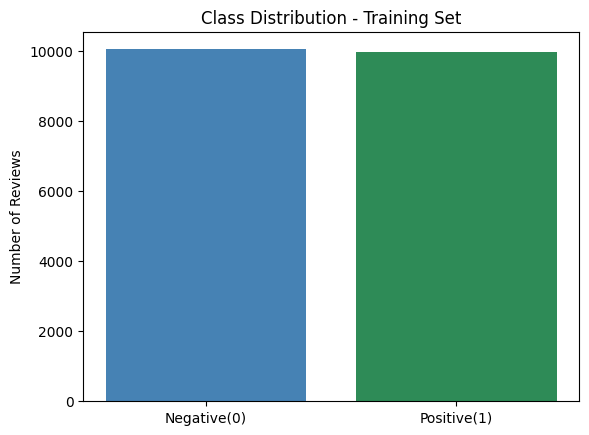



Class Percentage Distribution
0    50.19
1    49.81
dtype: float64


In [15]:
#Class Distribution:

plt.bar(['Negative(0)','Positive(1)'],[10038,9962],color=['steelblue','seagreen'])
plt.title('Class Distribution - Training Set')
plt.ylabel('Number of Reviews')

plt.show()

#Percentage distribution
print("\n")
print("Class Percentage Distribution")
counts = pd.Series({0:10038,1:9962})
percentages = counts/counts.sum() * 100

print(percentages)

The number of positive and negative reviews are almost the same which indicates there is no class imbalance.Or else SMOT technique or class_weight='balanced' can be used.

Positive reviews - 10038
Negative reviews - 9962

In [16]:
#Check for Missing or Empty Reviews

#Missing reviews

train_df['review'].isna().sum()

np.int64(0)

In [17]:

#Check for empty reviews or whitespaces

empty_str = (train_df['review'].str.strip()=="").sum()
print(f"There are {empty_str} empty string")

There are 0 empty string


We can conclude from the above that there are no missing values and empty reviews.

**Text Length Analysis:**
**Word/Character Count Distribution:**

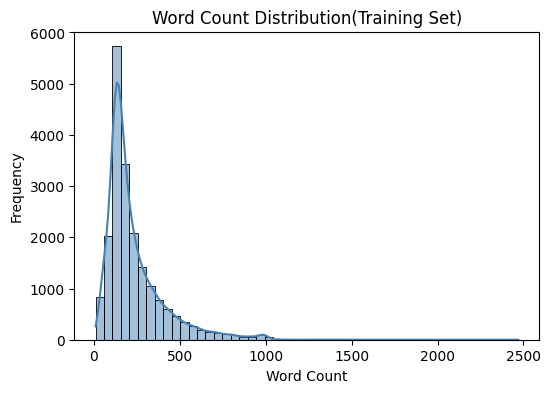

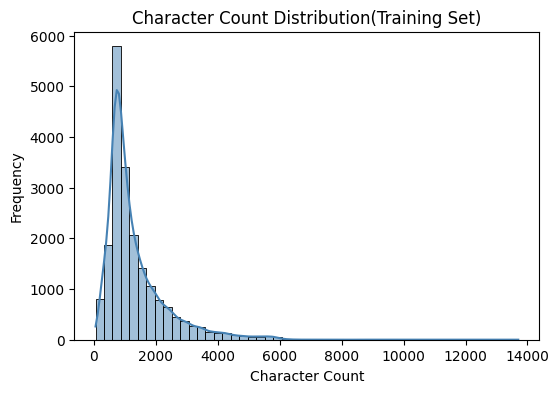

In [18]:
#Calculate Word count and character count

train_df['word_count']=train_df['review'].apply(lambda x:len(x.split()))
train_df['char_count'] = train_df['review'].apply(lambda x:len(x))

#Word Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['word_count'],bins=50,kde=True,color='steelblue')
plt.title('Word Count Distribution(Training Set)')
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#Character Count Distribution

plt.figure(figsize=(6,4))
sns.histplot(train_df['char_count'],bins=50,kde=True,color='steelblue')
plt.title('Character Count Distribution(Training Set)')
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

From the above 2 plots, we can see that most of the reviews have 50 to 200 words.Reviews greater than 500 words are very less. This means everyone prefers to write short reviews.

The character count plot also implies the same.

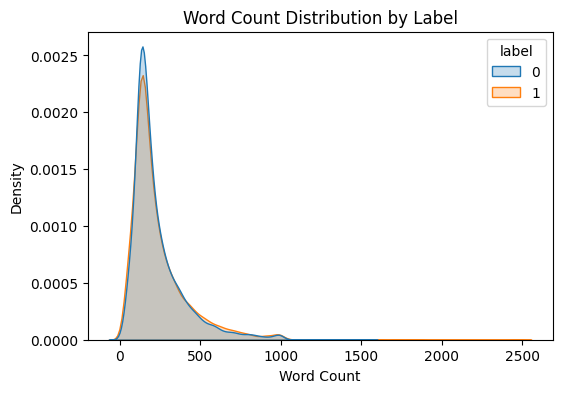

In [19]:
#Length Distributions Comparisons - Positive vs Negative reviews

plt.figure(figsize=(6,4))
sns.kdeplot(data=train_df,x='word_count',hue='label',fill=True)
plt.title('Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.show()

Most of the reviews whether positive or negative,are relatively short , around 200 to 400 words.Since both the curves overlap, this is not a strong review of the label(0 or 1).Very few reviews exceed 1000 words.

**Outlier Detection:**

Reviews the outlier reviews based on word count.
To find the shortest 1% of review and longest 1% of review.

In [20]:
#Identify Outliers

low_word_threshold = train_df['word_count'].quantile(0.01) #1st percentile thresholds
high_word_threshold = train_df['word_count'].quantile(0.99) #99th percentile thresholds

outliers_short = train_df[train_df['word_count'] <= low_word_threshold] #reviews with extremely low word count
outliers_long = train_df[train_df['word_count'] >= high_word_threshold] #reviews with extremely high wordd count

print("Very Short Reviews(bottom 1%)",outliers_short.shape[0])
print("Very long Reviews(top 1%)",outliers_long.shape[0])

print("\nExample of very short reviews")
print(outliers_short['review'].head(1).to_list())

print("\nExample of very long reviews")
print(outliers_long['review'].head(1).to_list())

Very Short Reviews(bottom 1%) 218
Very long Reviews(top 1%) 201

Example of very short reviews
['Great movie - especially the music - Etta James - "At Last". This speaks volumes when you have finally found that special someone.']

Example of very long reviews
['I\'m going to write about this movie and about "Irreversible" (the (in)famous scene in it). So you are warned, if you haven\'t seen the movie yet. This are just my thoughts, why I think the movie fails (in the end - pun intended).<br /><br />Acting wise, Rosario Dawson is really good and almost conveys portraying someone almost a decade younger (a teenager in other words). The villain guy is good, but loses his "evil" touch right before the end. If he really never changes, then why would he let a woman tie him up? He wouldn\'t, period. Then we also have the bartender/2nd rape Dude. Actually I don\'t think you would need him. At least not for the 2nd rape, but more about that later on.<br /><br />Let\'s reprise the story. Rosario

<Figure size 1200x500 with 0 Axes>

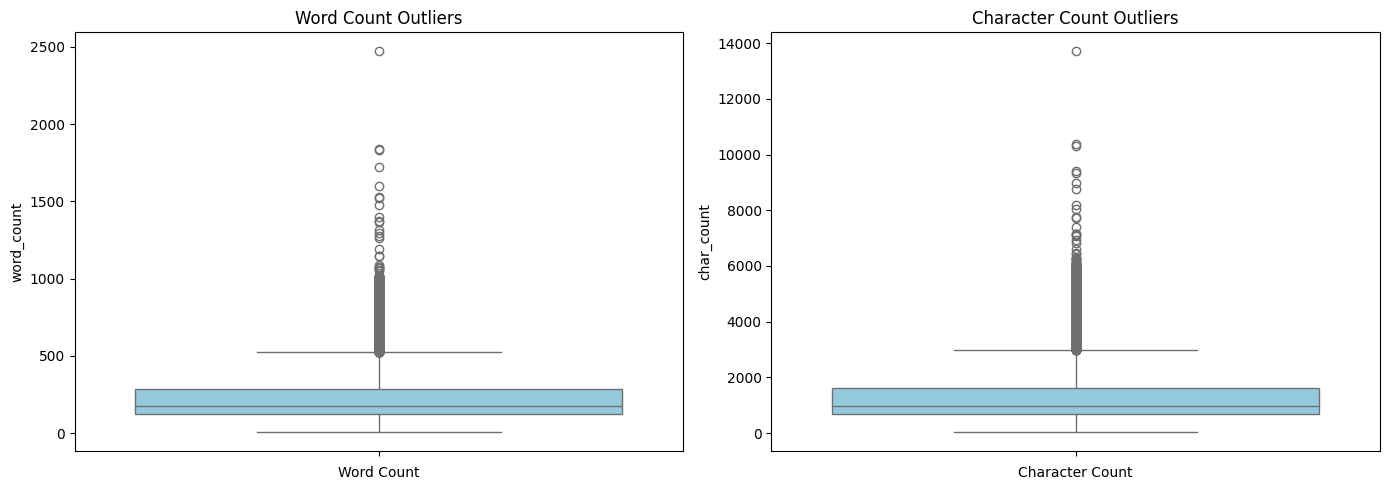

In [21]:
plt.figure(figsize=(12,5))

fig,axes = plt.subplots(1,2,figsize=(14,5))

#Word Count Boxplot
sns.boxplot(y=train_df['word_count'],ax=axes[0],color='skyblue')
axes[0].set_title("Word Count Outliers")
axes[0].set_xlabel('Word Count')

#Character Count boxplot
sns.boxplot(y=train_df['char_count'],ax=axes[1],color='skyblue')
axes[1].set_title("Character Count Outliers")
axes[1].set_xlabel('Character Count')

plt.tight_layout()
plt.show()


Word Count Outlier plot reveals that most of the words were between ~50  and within ~500.Dots above the whiskers are outliers - reviews that are usually long up to 2500 words.It might have excessive repetition etc.

Character Count Outlier plot reveals the same structure like word count.Most reviews are under ~ 4000 characters.But ouliers stretch to 14000 characters. This might have html tags,punctuation etc. which will be removed during data processing.

**Vocabulary-Level EDA**

/tmp/ipython-input-2436678500.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
/tmp/ipython-input-2436678500.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
/tmp/ipython-input-2436678500.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
/tmp/ipython-input-2436678500.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabe

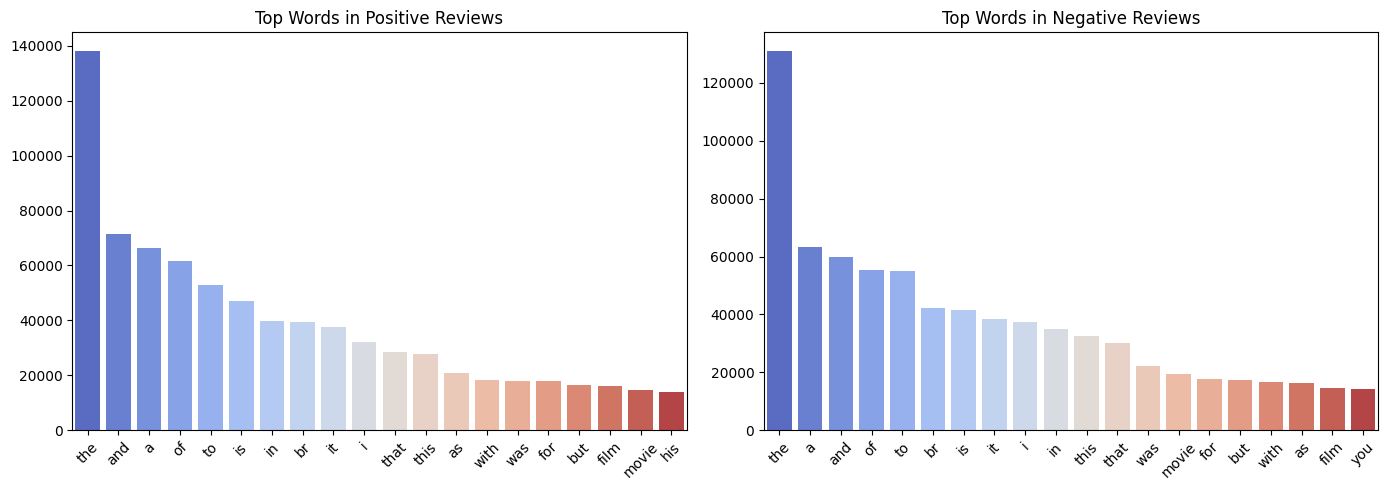

In [22]:
#Most Frequent words(raw counts)
stop_words = set(stopwords.words('english'))

def tokenize(text):
  tokens = word_tokenize(text.lower())
  tokens = [t for t in tokens if t.isalpha()]

  return tokens
train_df['tokens'] = train_df['review'].apply(tokenize)

#Frequent words per class

def get_top_words_by_class(df,label,top_n=20):
  words = [word for tokens in df[df['label']==label]['tokens']for word in tokens]
  return Counter(words).most_common(top_n)

pos_words = get_top_words_by_class(train_df,1)
neg_words = get_top_words_by_class(train_df,0)

fig,axes = plt.subplots(1,2,figsize=(14,5))
for ax,data,title in zip(axes,[pos_words,neg_words],['Positive','Negative']):
  words,counts = zip(*data)
  sns.barplot(x=list(words),y=list(counts),ax=ax,palette='coolwarm')
  ax.set_title(f'Top Words in {title} Reviews')
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

plt.tight_layout()
plt.show()

This shows the top frequent 20 words in Positive and Negative reviews.

From the above 2 plots,we can see that the word 'The' has maximum count for both positive and negative reviews.

In [23]:
train_df.head()

,review,label,clean_review,word_count,char_count,tokens
0,"""Pandemonium"" is a horror movie spoof that com...",0,pandemoniumisahorrormoviespoofthatcomesoffmore...,135,751,"[pandemonium, is, a, horror, movie, spoof, tha..."
1,David Mamet is a very interesting and a very u...,0,davidmametisaveryinterestingandaveryunequaldir...,205,1180,"[david, mamet, is, a, very, interesting, and, ..."
2,Great documentary about the lives of NY firefi...,1,greatdocumentaryaboutthelivesofnyfirefightersd...,125,702,"[great, documentary, about, the, lives, of, ny..."
3,It's boggles the mind how this movie was nomin...,0,itsbogglesthemindhowthismoviewasnominatedforse...,342,1969,"[it, boggles, the, mind, how, this, movie, was..."
4,The concept of the legal gray area in Love Cri...,0,theconceptofthelegalgrayareainlovecrimescontri...,269,1511,"[the, concept, of, the, legal, gray, area, in,..."


/tmp/ipython-input-1370144885.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words),y=list(counts),palette='gray')


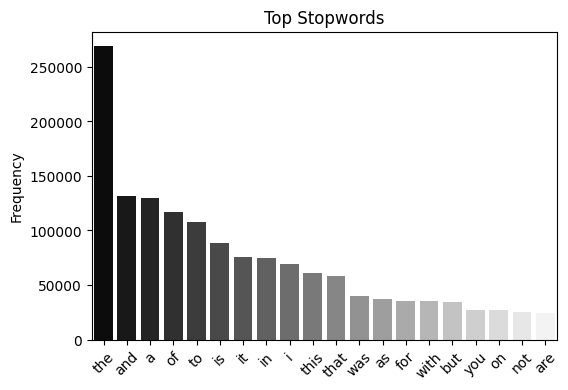

In [24]:
#Stopword Frequency

train_df['tokens']

all_words = [word for tokens in train_df['tokens'] for word in tokens]
stopword_counts = Counter([word for word in all_words if word in stop_words])
top_stopwords = stopword_counts.most_common(20)
words,counts = zip(*top_stopwords)

plt.figure(figsize=(6,4))
sns.barplot(x=list(words),y=list(counts),palette='gray')
plt.title('Top Stopwords')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()

Stopwords are words that are very common and don't add any meaningful information to the text analysis. The above plot shows the top 20 stopwords in both positive and negative reviews. The word 'The' has a frequency of more than 250K.

In [25]:
#Rare words count

word_freq =  [word for tokens in train_df['tokens'] for word in tokens]
word_freq_list = Counter(word_freq)

rare_words = [word for word,count in word_freq_list.items() if count==1]
print(f"Total length of rare words: {len(rare_words)}")
print(f"Total Vocabulary size:{len(word_freq)}")

Total length of rare words: 24062
Total Vocabulary size:4609286


**Word Cloud:**

Using a word cloud, we can see the most frequent words in the text collection. Most frequent words appear larger and less frequent words appear smaller. They are mainly used to find the difference between positive and negative reviews.

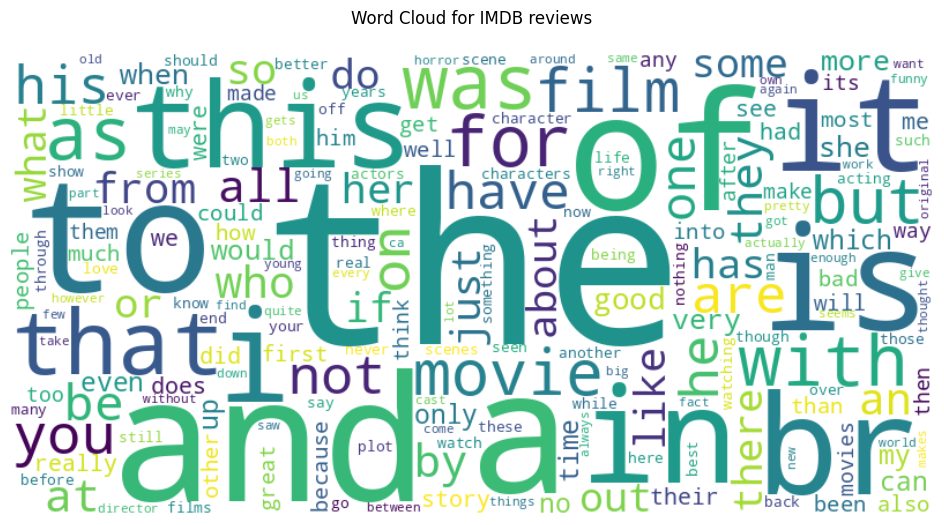

In [27]:
word_freq = Counter(all_words)

wordcloud = WordCloud(width=800,height=400,background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for IMDB reviews\n")
plt.show()


From above,we can see that the most frequent words are 'the','this','a','in','to','br','it' etc.Most of these are stopwords and they dont add any meaning to the analysis.So all the stop words will be removed during the data cleaning and processing step.

**N-grams:**

N-gram is a sequence of n consecutive words taken from the text.

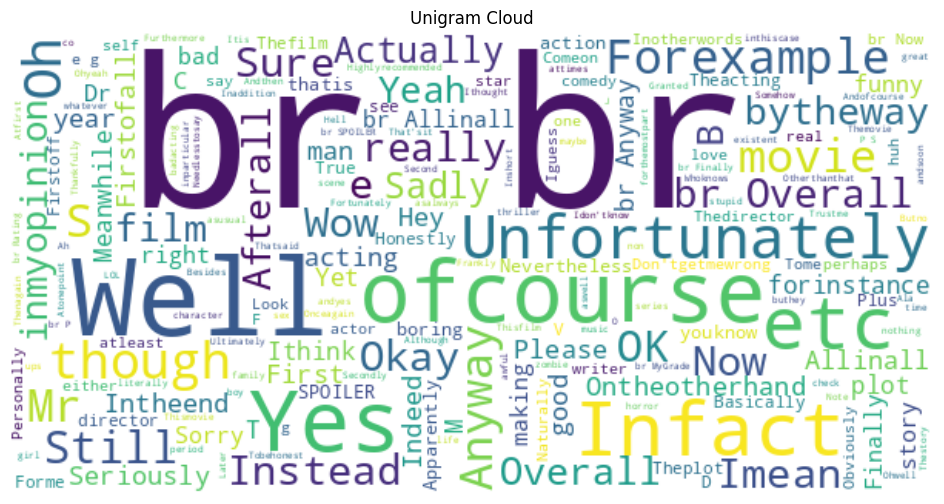

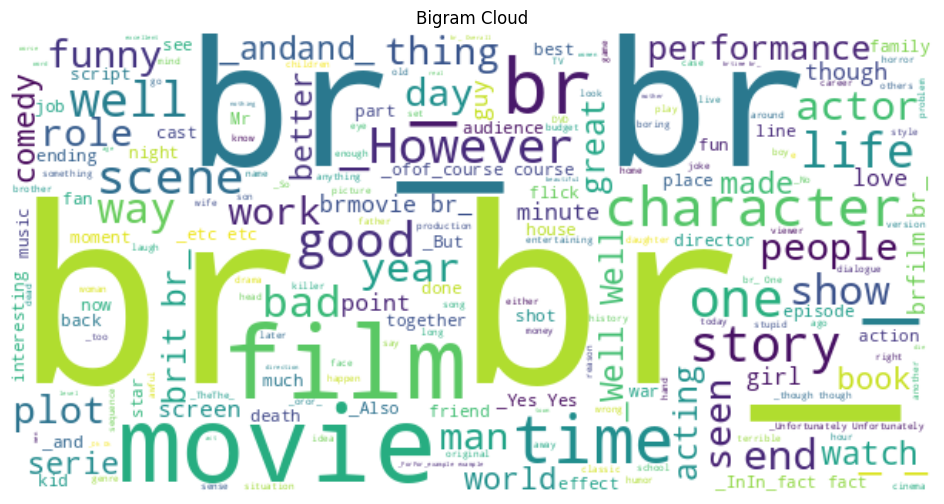

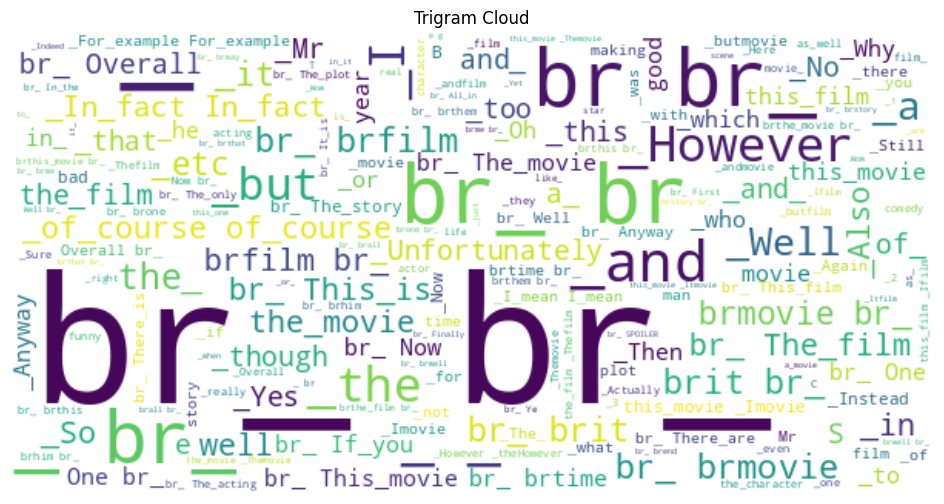

In [28]:
#N-grams for the entire training dataset

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

unigrams = generate_all_ngrams(train_df['review'],1)
bigrams = generate_all_ngrams(train_df['review'],2)
trigrams = generate_all_ngrams(train_df['review'],3)

unigram_counts = Counter(unigrams)
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

unigram_text = "".join(["_".join(u) for u in unigrams])
bigram_text = "".join(["_".join(b) for b in bigrams])
trigram_text = "".join(["_".join(t) for t in trigrams])

def show_cloud(text,title):
  wc = WordCloud(width=600,height=300,background_color='white').generate(text)
  plt.figure(figsize=(12,6))
  plt.imshow(wc,interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

show_cloud(unigram_text,"Unigram Cloud")
show_cloud(bigram_text,"Bigram Cloud")
show_cloud(trigram_text,"Trigram Cloud")

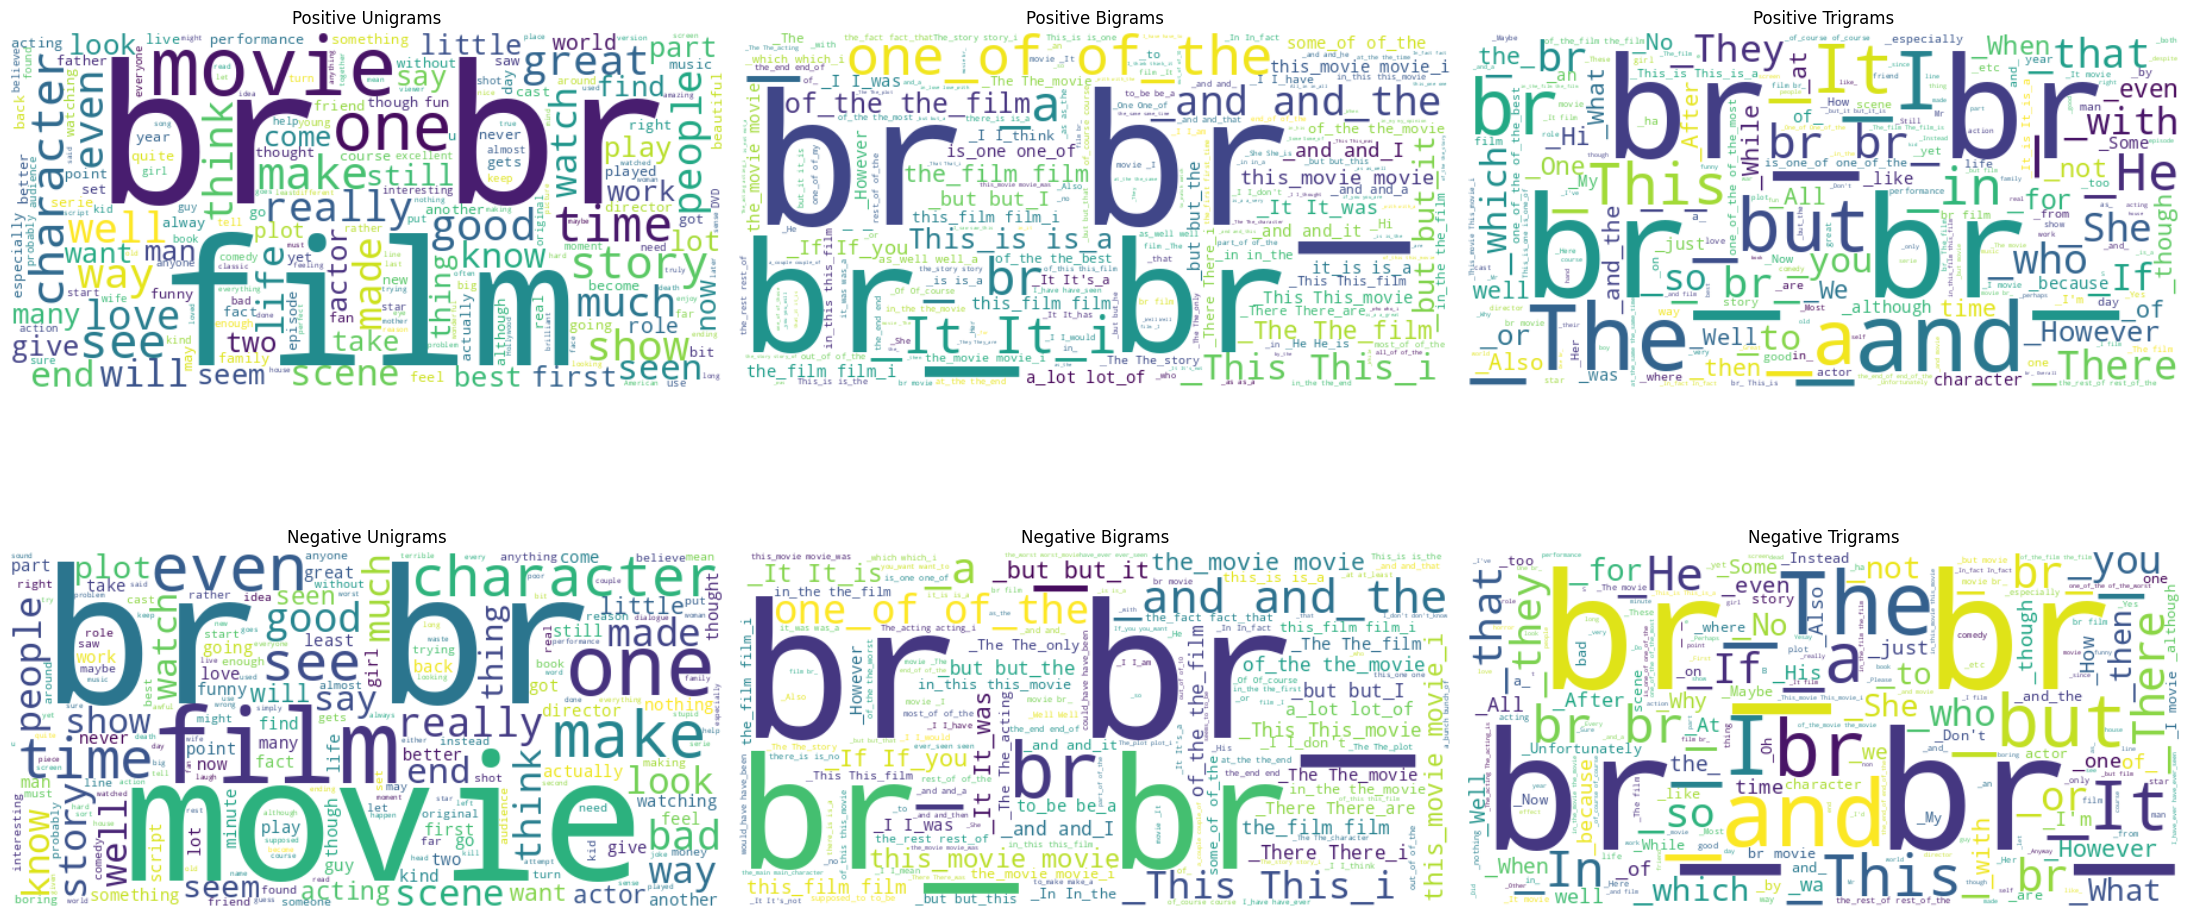

In [29]:
#Separate N-grams for positive and negative reviews

pos_reviews = train_df[train_df['label']==1]['review']
neg_reviews = train_df[train_df['label']==0]['review']

def generate_ngrams(text,n):
  tokens = text.split()
  return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def generate_all_ngrams(series,n):
  all_ngrams = []
  for text in series:
    all_ngrams.extend(generate_ngrams(text,n))
  return all_ngrams

pos_unigrams = generate_all_ngrams(pos_reviews,1)
pos_bigrams = generate_all_ngrams(pos_reviews,2)
pos_trigrams = generate_all_ngrams(pos_reviews,3)

neg_unigrams = generate_all_ngrams(neg_reviews,1)
neg_bigrams = generate_all_ngrams(neg_reviews,2)
neg_trigrams = generate_all_ngrams(neg_reviews,3)

def ngrams_to_text(ngrams):
  return " ".join(["_".join(t) for t in ngrams])

pos_uni_text = ngrams_to_text(pos_unigrams)
pos_bi_text = ngrams_to_text(pos_bigrams)
pos_tri_text = ngrams_to_text(pos_trigrams)

neg_uni_text = ngrams_to_text(neg_unigrams)
neg_bi_text = ngrams_to_text(neg_bigrams)
neg_tri_text = ngrams_to_text(neg_trigrams)

def make_cloud(text):
  return WordCloud(width=600,height=300,background_color='white').generate(text)

fig,axes = plt.subplots(2,3,figsize=(22,12))

#Positive

axes[0,0].imshow(make_cloud(pos_uni_text),interpolation='bilinear')
axes[0,0].set_title("Positive Unigrams")
axes[0,0].axis("off")

axes[0,1].imshow(make_cloud(pos_bi_text),interpolation='bilinear')
axes[0,1].set_title("Positive Bigrams")
axes[0,1].axis("off")

axes[0,2].imshow(make_cloud(pos_tri_text),interpolation='bilinear')
axes[0,2].set_title("Positive Trigrams")
axes[0,2].axis("off")

#Negative

axes[1,0].imshow(make_cloud(neg_uni_text),interpolation='bilinear')
axes[1,0].set_title("Negative Unigrams")
axes[1,0].axis("off")

axes[1,1].imshow(make_cloud(neg_bi_text),interpolation='bilinear')
axes[1,1].set_title("Negative Bigrams")
axes[1,1].axis("off")

axes[1,2].imshow(make_cloud(neg_tri_text),interpolation='bilinear')
axes[1,2].set_title("Negative Trigrams")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()


This code computes TF-IDF score for all words in training reviews, then identifies the top 10 most important words for positive and negative reviews.All the words are then visualized using a barchart.

Top positive TF-IDF words:
br:0.1057
movie:0.0511
film:0.0508
great:0.0258
good:0.0254
like:0.0250
story:0.0233
just:0.0211
time:0.0205
really:0.0195
Top negative TF-IDF words:
br:0.1200
movie:0.0666
film:0.0483
bad:0.0323
just:0.0319
like:0.0314
good:0.0251
really:0.0228
time:0.0215
don:0.0214


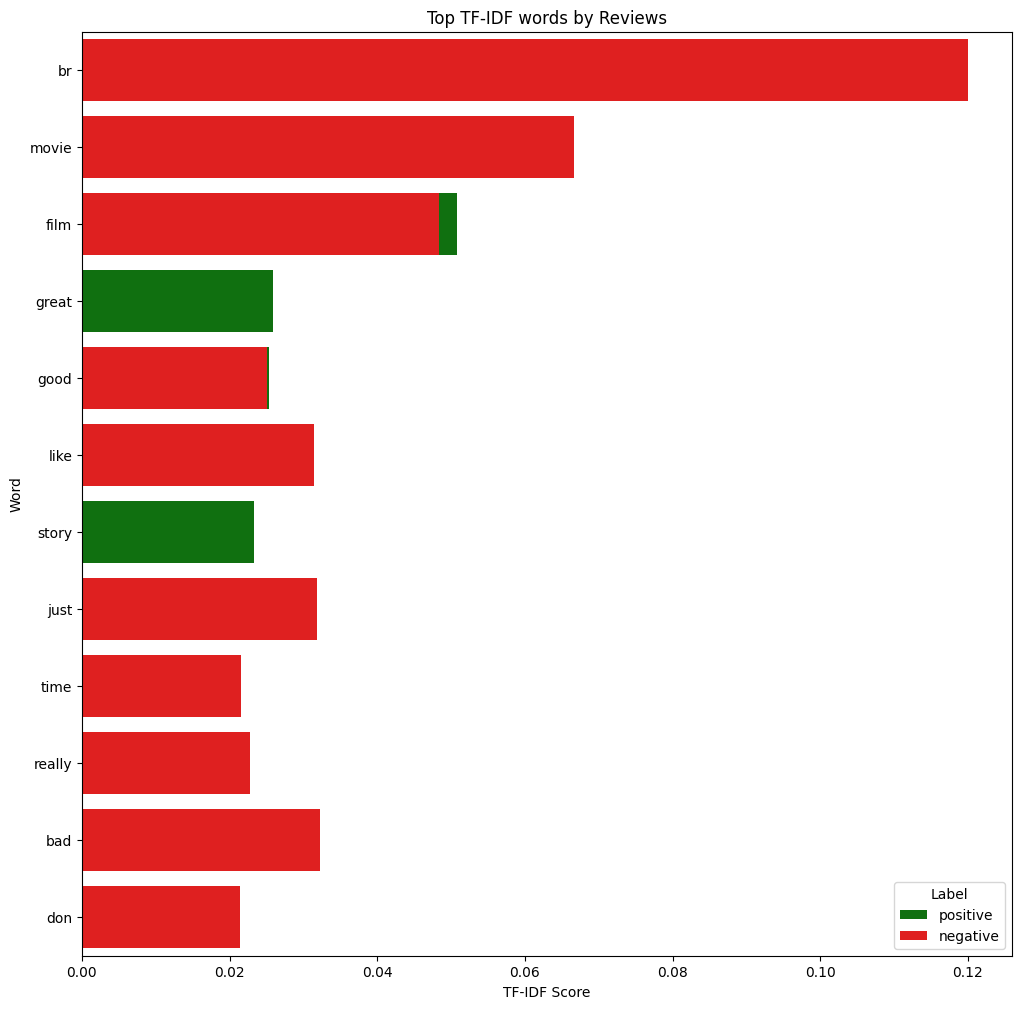

In [30]:
#TF-IDF Visualisation

tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,1),stop_words='english')

X = tfidf.fit_transform(train_df['review'])
feature_names = tfidf.get_feature_names_out()

pos_idx = train_df['label']==1
neg_idx = train_df['label']==0

X_pos = X[pos_idx.values]
X_neg = X[neg_idx.values]

pos_mean = np.asarray(X_pos.mean(axis=0)).ravel()
neg_mean = np.asarray(X_neg.mean(axis=0)).ravel()

top_n = 10

pos_top_idx = pos_mean.argsort()[-top_n:][::-1]
neg_top_idx = neg_mean.argsort()[-top_n:][::-1]

pos_top_words = [(feature_names[i],pos_mean[i]) for i in pos_top_idx]
neg_top_words = [(feature_names[i],neg_mean[i]) for i in neg_top_idx]

print("Top positive TF-IDF words:")
for word,score in pos_top_words:
  print(f"{word}:{score:.4f}")

print("Top negative TF-IDF words:")
for word,score in neg_top_words:
  print(f"{word}:{score:.4f}")

#Heatmap

df_heat = pd.DataFrame({"word":[w for w,s in pos_top_words] + [w for w,s in neg_top_words],
                        "score":[s for w,s in pos_top_words] + [s for w,s in neg_top_words],
                        "Label":["positive"]*top_n+["negative"]*top_n})

plt.figure(figsize=(12,12))
sns.barplot(data=df_heat,y="word",x="score",hue="Label",dodge=False,palette=["green","red"])
plt.title("Top TF-IDF words by Reviews")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.show()

## EDA Summary

1. **Class Imbalance** - I checked for class imbalance and found that the number of positive and negative reviews are almost the same.So , no additional processing is required.

2. **Check for Missing reviews** - There are no empty strings in the dataset.

3. **WordCount/Character Distribution -** Most of the reviews have 50 to 200 words.

4. **Outlier Detection** - There are 218 short reviews and 201 long reviews.The character count of long reviews are close to 14000.

5. **Most Frequent words in Positive and Negative reviews** - Mostly the stopwords are the most frequent words in both the positive and negative reviews and they will be removed during the processing step.

6. **Top 20 Stopwords and their frequency**

7. **Rare words Count**

8. **WordCloud** - As discussed earlier, word cloud showed that the stop words are more dominant and this can be removed during cleaning since they dont add any value to the sentiment analysis.

9. **N-grams for Positive and Negative reviews**

10.**TF-IDF Visulaization** - Found the top 20 words in positive and negative reviews based on their TF-IDF scores

# Data Preprocessing and Cleaning

The following steps were performed as part of Cleaning and Preprocessing.

1. Converts the text to lowercase, removes HTML tags, and removes punctuation using a regex pattern
2. Text vectorization layer is created to convert the raw text into a sequence of integers.
3. Extracts only the text from the training dataset.adapt() learns only the vocabulary from the training data.
4. Vectorization is applied to the train, test, and val datasets.
5. Optimizing the data pipeline (For fastertraining - prefetching the next batch when the model trains the current batch)

In [31]:
#Function to strip HTML tags and punctuations

def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  removed_html = tf.strings.regex_replace(lowercase,'<br/>','')
  #removed_html = tf.strings.regex_replace('[^A-Za-z]','')
  #removed_html = tf.strings.regex_replace("\s+",'')
  return tf.strings.regex_replace(removed_html,f'[{re.escape(string.punctuation)}]','')

max_features = 10000 #Maximum Vocabulary size
sequence_length = 250  #Pad reviews

#Create Vectorizer
vectorize_layer = TextVectorization(standardize = custom_standardization,
                                    max_tokens=max_features,
                                    output_mode='int',
                                    output_sequence_length=sequence_length)

#Adapt on training data
train_text = raw_train_ds.map(lambda x,y:x)
vectorize_layer.adapt(train_text)

#Apply vectorization to all datasets
def vectorize_text(text,label):
  text = tf.expand_dims(text,-1)
  return vectorize_layer(text),label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

#Optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Model Building and Interpretation:

## 1.BaseLine Model:

In [72]:
#Baseline Model:

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

model = keras.Sequential([layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.GlobalAveragePooling1D(), #average all the wordvectorsin teh sequence
                          layers.Dense(16,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

#Compile the model

model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history = model.fit(train_ds,validation_data=val_ds,epochs=5)
model.summary()
#Evaluate
#val_loss,val_acc = model.evaluate(val_ds)
#print('Validation Accuracy',val_acc)
#print('Validation Loss',val_loss)

val_acc    = max(history.history['val_accuracy'])
val_loss   = min(history.history['val_loss'])
print('Validation Accuracy',val_acc)
print('Validation Loss',val_loss)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6023 - loss: 0.6426 - val_accuracy: 0.8526 - val_loss: 0.3704
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8550 - loss: 0.3459 - val_accuracy: 0.8680 - val_loss: 0.3136
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8918 - loss: 0.2675 - val_accuracy: 0.8654 - val_loss: 0.3083
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9096 - loss: 0.2280 - val_accuracy: 0.8640 - val_loss: 0.3179
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9219 - loss: 0.2006 - val_accuracy: 0.8606 - val_loss: 0.3361


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,843,173 (14.66 MB)

 Trainable params: 1,281,057 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,562,116 (9.77 MB)

Validation Accuracy 0.8679999709129333
Validation Loss 0.3083406090736389


**Evaluation Metrics (Baseline Model):**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━

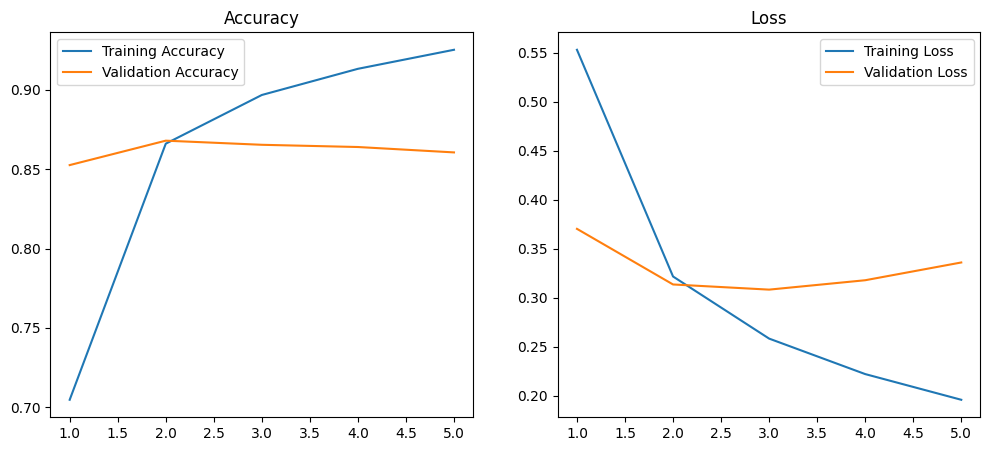

In [75]:
#Baseline Evaluation Metrics


y_true_baseline=[]
y_pred_baseline=[]

for text_batch,label_batch in val_ds:
  preds = model.predict(text_batch)
  y_true_baseline.extend(label_batch.numpy())
  y_pred_baseline.extend((preds>0.5).astype('int32'))

cm_baseline = confusion_matrix(y_true_baseline,y_pred_baseline)
print(cm_baseline)

print(classification_report(y_true_baseline,y_pred_baseline))

history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()


**Baseline Summary:**

The accuracy of the baseline model is ~0.867 which is good for a baseline model.This can be used as a benchmark to compare with the other models.

Model is slightly better at correctly identifying negative reviews(higher recall for class 0) and slightly better at being accurate when predicting positive reviews.

This is confirmed in the classification Report summary.Negative reviews have higher recall and F1 score than the positive reviews (0 - 0.90, 1 - 0.83)

**Acccuracy Plot:**

Training accuracy keeps increasing , which means the model is learning patterns from the training data.

Validation accuracy improves initially and then pleteaus showing that the model stops gaining new generalization.

**Loss Plot:**

Training loss steadily decreases and then becomes closer to 0 which means the model is overfitting.

Validation loss decreases initially but starts raising after few epoch 2

Baseline model's best performance is around epoch 2 or 3.

## 2.BiLSTM (Standard):

BiLSTM captures the information both forward and backward thereby capturing more contextual information.It is good at capturing negation,contrast etc.(like 'Not Good').

1. The model has an Embedding layer that converts each of the 20000 words into 64 dimensional vectors.
2. Next is Bidirectional LSTM layer with 64 units.
3. A dense layer with 32 units to learn the non linear patterns.
4. Output layer with sigmoid activation to predict the output.

In [35]:
#Used the same parameters I have used in baseline for comparison

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
                          layers.Bidirectional(layers.LSTM(64,return_sequences=False)) ,
                          layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
                          layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model

history_bilstm = bilstm_model.fit(train_ds,validation_data=val_ds,epochs=5)

#Evaluate
val_loss_bilstm,val_acc_bilstm = bilstm_model.evaluate(val_ds)
print('Val Accuracy',val_acc_bilstm)
print('Val Loss',val_loss_bilstm)



Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.6500 - loss: 0.5944 - val_accuracy: 0.6924 - val_loss: 0.5956
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8275 - loss: 0.3868 - val_accuracy: 0.8562 - val_loss: 0.3588
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8749 - loss: 0.3083 - val_accuracy: 0.8548 - val_loss: 0.3766
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9183 - loss: 0.2341 - val_accuracy: 0.8566 - val_loss: 0.4185
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9376 - loss: 0.1821 - val_accuracy: 0.8552 - val_loss: 0.4182
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8579 - loss: 0.4104
Val Accuracy 0.8551999926567078
Val Loss 0.4181536138057709


In [37]:
#Used the same parameters I have used in baseline for comparison
#and added regularization,early stopping

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#BiLSTM model
bilstm_model_1 = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.3),

    layers.Bidirectional(layers.LSTM(32,dropout=0.3)) ,
    layers.Dense(32,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

bilstm_model_1.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
#Train Model

history_bilstm_1 = bilstm_model_1.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop])
bilstm_model_1.summary()
#Evaluate
val_loss_bilstm_1,val_acc_bilstm_1 = bilstm_model_1.evaluate(val_ds)
print('Val Accuracy',val_acc_bilstm_1)
print('Val Loss',val_loss_bilstm_1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.6024 - loss: 0.6452 - val_accuracy: 0.7336 - val_loss: 0.5649
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8065 - loss: 0.4570 - val_accuracy: 0.8388 - val_loss: 0.3846
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8775 - loss: 0.3228 - val_accuracy: 0.8686 - val_loss: 0.3229
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9041 - loss: 0.2652 - val_accuracy: 0.8646 - val_loss: 0.3300
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9142 - loss: 0.2390 - val_accuracy: 0.8672 - val_loss: 0.3688


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 250, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,920,837 (14.96 MB)

 Trainable params: 1,306,945 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,613,892 (9.97 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8720 - loss: 0.3143
Val Accuracy 0.8686000108718872
Val Loss 0.32288506627082825


1. The model stopped at epoch = 5,This is because early stopping detected that there is val_loss is no longer improving.
2. Since restore_weights = True, weigts where the val_loss is lowest is used.
3. In Epoch 3, the loss is very low.In epoch 4 and 5 , the val loss kept increasing from 0.33 to 0.36
4. The fact that the val loss began to increase shows the model began to memorize the patterns rather than generalizing.
5. The model has a Val accuracy of 0.8686 (Val accuracy when the loss is low)

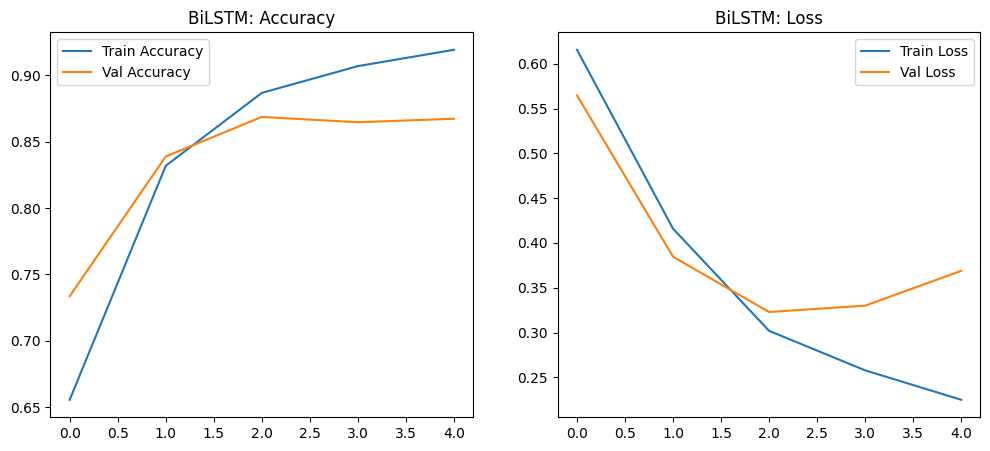

In [38]:
#Training Curve:

#BiLSTM Training Curve

acc_bilstm = history_bilstm_1.history['accuracy']
val_acc_bilstm = history_bilstm_1.history['val_accuracy']
loss_bilstm = history_bilstm_1.history['accuracy']
val_loss_bilstm = history_bilstm_1.history['val_loss']

epochs_bilstm = range(1,len(acc_bilstm)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_bilstm_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm_1.history['val_accuracy'], label='Val Accuracy')
plt.title('BiLSTM: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_bilstm_1.history['loss'], label='Train Loss')
plt.plot(history_bilstm_1.history['val_loss'], label='Val Loss')
plt.title('BiLSTM: Loss')
plt.legend()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      2462
           1       0.85      0.90      0.87      2538

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



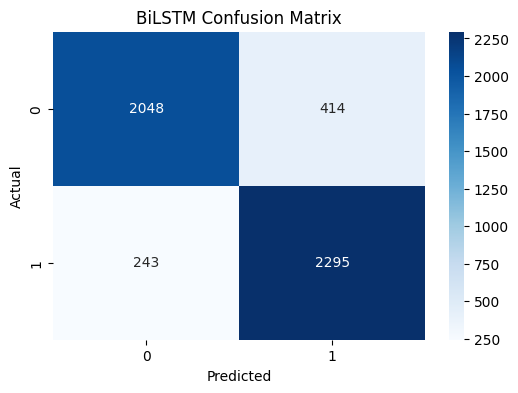

In [39]:
#Evaluation Metric:

#Classification Report
y_true_bilstm = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_bilstm = bilstm_model_1.predict(val_ds)
y_pred_bilstm = (y_pred_probs_bilstm > 0.5).astype("int32")

print(classification_report(y_true_bilstm, y_pred_bilstm))

#Confusion Matrix

cm_bilstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_bilstm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")
plt.show()

The majority of reviews are correctly identified. (TP - 2048,TN - 2295)
FN - 414 (Model thought these positives as Negatives)
FP - 243

The model shows that model is well balanced with equal number of positive and negative reviews.The classification report matrix shows that the f1 score is strong 0.86.

## 3.BiLSTM (Tuned)

In [40]:
#Hyperparameter Tuning BiLSTM
#Units - [32,64,96]
#dropout - [0.2,0.3,0.4]
#learning rate - [1e-3]

def build_model_bilstm(bilstm):
    # 1. Tune the number of units in the LSTM layer
    # Choose an optimal value between 32-64
    bilstm_units = bilstm.Int('units', min_value=32, max_value=96, step=32)

    # 2. Tune the dropout rate
    bilstm_dropout = bilstm.Float('dropout', min_value=0.2, max_value=0.3, step=0.1)

    # 3. Tune the learning rate
    bilstm_learning_rate = bilstm.Choice('learning_rate', values=[1e-3])

    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
        layers.SpatialDropout1D(0.3),

        # Removed recurrent_dropout for CuDNN speed
        layers.Bidirectional(layers.LSTM(units=bilstm_units, dropout=bilstm_dropout)),

        layers.Dense(bilstm_units, activation='relu'),
        layers.Dropout(bilstm_dropout),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=bilstm_learning_rate),
        loss='binary_crossentropy',
            metrics=['accuracy']
        )
    return model

    # Initialize the Tuner (Hyperband is efficient)
tuner_bilstm = kt.Hyperband(
        build_model_bilstm,
        objective='val_accuracy',
        max_epochs=5,
        factor=3,
        directory='my_dir',
        project_name='imdb_bilstm_tuning'
    )

    # Early stopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    # Start searching
tuner_bilstm.search(train_ds, validation_data=val_ds, epochs=5, callbacks=[early_stop],verbose=2)

    # Get the best model
best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]



Trial 3 Complete [00h 00m 33s]
val_accuracy: 0.8637999892234802

Best val_accuracy So Far: 0.8637999892234802
Total elapsed time: 00h 01m 40s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [41]:

best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]

print("Best Units:",best_hps_bilstm.get('units'))
print("Best dropout:",best_hps_bilstm.get('dropout'))
print("Learning rate:",best_hps_bilstm.get('learning_rate'))

best_hps_bilstm.values

final_bilstm_model = tuner_bilstm.hypermodel.build(best_hps_bilstm)

history_bilstm_tuned = final_bilstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop],
    verbose=2
)



Best Units: 32
Best dropout: 0.2
Learning rate: 0.001
Epoch 1/5
625/625 - 17s - 27ms/step - accuracy: 0.7438 - loss: 0.5138 - val_accuracy: 0.8544 - val_loss: 0.3656
Epoch 2/5
625/625 - 14s - 22ms/step - accuracy: 0.8712 - loss: 0.3322 - val_accuracy: 0.8142 - val_loss: 0.4009
Epoch 3/5
625/625 - 14s - 22ms/step - accuracy: 0.9003 - loss: 0.2653 - val_accuracy: 0.8602 - val_loss: 0.3678


In [42]:
#Evaluation Metric for the best model


best_model_bilstm = tuner_bilstm.get_best_models(num_models=1)[0]

y_true_bilstm_tuned = np.concatenate([y for x,y in val_ds],axis=0)
y_pred_probs_bilstm_tuned = best_model_bilstm.predict(val_ds)
y_pred_bilstm_tuned = (y_pred_probs_bilstm_tuned > 0.5).astype("int32")

print("=== Final Evaluation Report: BiLSTM Model===")
print(classification_report(y_true_bilstm_tuned,y_pred_bilstm_tuned,target_names=['Negative','Positive']))

#Best Hyperparameters

best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
=== Final Evaluation Report: BiLSTM Model===
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.87      2462
    Positive       0.89      0.84      0.86      2538

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000




 === Optimized Best Hyperparameters ===
LSTM Units: 32
Dropout Rate: 0.2
Learning Rate: 0.001


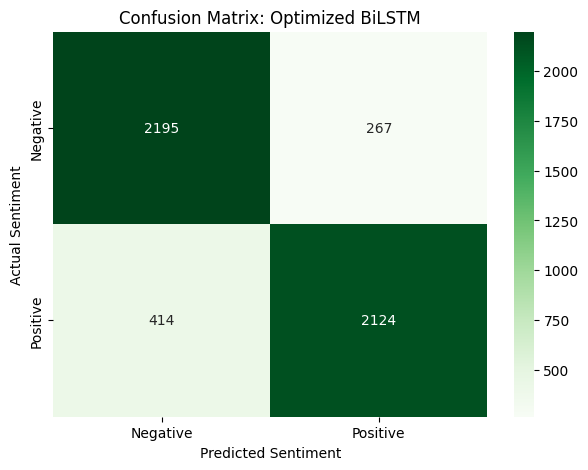

In [44]:
print("\n === Optimized Best Hyperparameters ===")
print(f"LSTM Units: {best_hps_bilstm.get('units')}")
print(f"Dropout Rate: {best_hps_bilstm.get('dropout')}")
print(f"Learning Rate: {best_hps_bilstm.get('learning_rate')}")

#Confusion Matrix

cm_bilstm_tuned = confusion_matrix(y_true_bilstm_tuned, y_pred_bilstm_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_bilstm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix: Optimized BiLSTM')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

Analysis:

1. The model utilized Early stopping .Out of 10 epochs, it stopped at epoch = 3 because validation loss stops to increase.
2. Since the validation loss is very low at epoch =1, model keeps its weights.
3. The model achieved accuracy of 0.85
4. The confusion matrix shows that most of the reviews are identified correctly (TP - 2195,TN - 2124)
5. It also shows that the model makes mistakes in predicting the False positives and negatives almost equally.
6. The classification report shows that the F1 score is  0.87 which is a good score.

## 4.1D CNN (Standard):
While BiLSTM reads word by word in both the directions,1D CNN uses filers to slide across the sentence to pick the patterns.

**Architecture:**

*   Embedding Layer - Turns words into vectors
*   Convolution Layer - Learns local patters(n-grams)
*   Global MaxPooling - Pickts the most important feature from the window
*   Dense Layer - To learn complex patterns
*   Dropout - Reduce overfitting
*   Dense Layer - Makes the final prediction



In [46]:
#1DCNN

vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#1DCNN model
cnn_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.2),
    layers.Conv1D(filters=64,kernel_size=5,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)) ,
    layers.GlobalMaxPooling1D(),
    layers.Dense(64,activation='relu'), #learns hidden patterns(Non linear combinations)
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')]) #Output layer

cnn_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
early_stop_cnn = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2)
history_cnn_standard = cnn_model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop_cnn])
cnn_model.summary()

#Evaluate
val_loss_cnn,val_acc_cnn = cnn_model.evaluate(val_ds)
print('CNN Val Accuracy',val_acc_cnn)
print('CNN Val Loss',val_loss_cnn)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6396 - loss: 0.6400 - val_accuracy: 0.8424 - val_loss: 0.3885
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8609 - loss: 0.3629 - val_accuracy: 0.8660 - val_loss: 0.3464
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9234 - loss: 0.2394 - val_accuracy: 0.8668 - val_loss: 0.3736
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9615 - loss: 0.1553 - val_accuracy: 0.8646 - val_loss: 0.4149


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 250, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 246, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,914,309 (14.93 MB)

 Trainable params: 1,304,769 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,609,540 (9.95 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.4027
CNN Val Accuracy 0.8646000027656555
CNN Val Loss 0.41486573219299316


The 1D CNN model show signs of overfitting .The training loss starts at 0.64 and decreases to 0.15 while the validation loss increases from 0.38 to 0.41.This indicates that the model begins to capture noise specific to the training set rather than broad sentiment patterns.

Early stopping is used to stop at the moment the validation loss starts improving.

Next,I am going to use keras Tuner find the best set of hyperparameters of 1D CNN model.


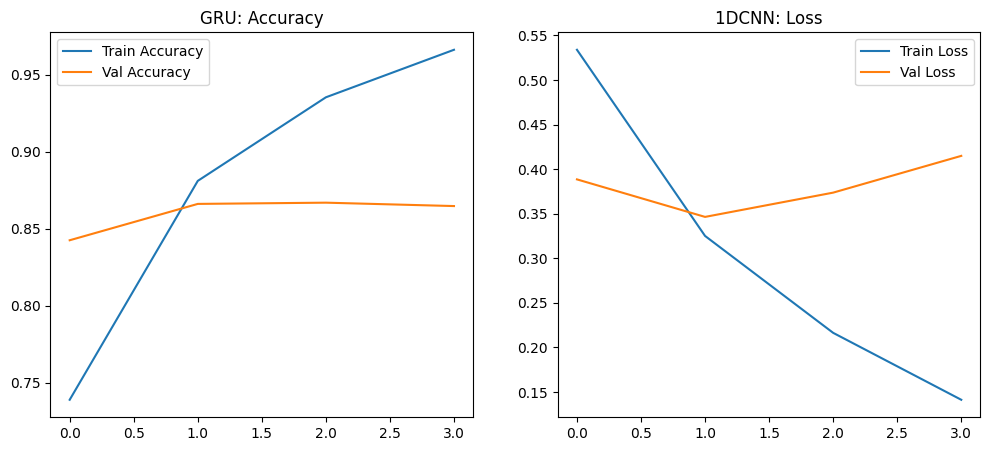

In [47]:
#1DCNN Training Curve

acc_cnn = history_cnn_standard.history['accuracy']
val_acc_cnn = history_cnn_standard.history['val_accuracy']
loss_cnn = history_cnn_standard.history['accuracy']
val_loss_cnn = history_cnn_standard.history['val_loss']

epochs = range(1,len(acc_cnn)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn_standard.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_standard.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn_standard.history['loss'], label='Train Loss')
plt.plot(history_cnn_standard.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      2462
           1       0.85      0.89      0.87      2538

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



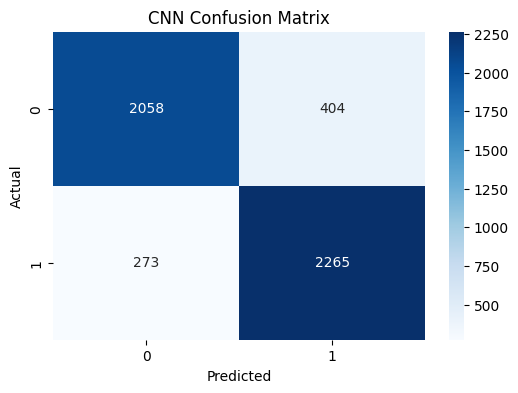

In [48]:
#Classification Report
y_true_cnn = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn = cnn_model.predict(val_ds)
y_pred_cnn = (y_pred_probs_cnn > 0.5).astype("int32")

print(classification_report(y_true_cnn, y_pred_cnn))

#Confusion Matrix

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()



**Accuracy Graph**

*   Training accuracy starts very low and becomes closer to 1 by last epochs.
*   Validation accuracy begins at 84% , briefly increases a bit to 86% and then almost remains the same till the last epochs.
*   This means that the model is memorizing and it will work only on the training data and not on the unseen validation data.

**Loss Graph:**

*   Training Loss decreases rapidly from 0.64 to near ~0.15 , which shows almost perfect training accuracy.
*   Validation loss, on the other hand, starts low and then increases across epochs, confirming that additional training will increase it further.
*   This indicates a sign of overfitting.

Keras Tuner gave the best possible hyperparamater combination based on the highest Validation accuracy.But from the above 2 plots, we found that there is a classic sign of overfitting.So, picking the epoch with the lowest validation loss which tells when to stop training for a given hyperparameter set.






## 5.1D CNN(Tuned)

In [49]:
#In the same hyperparameter tuning I used earlier, am going to change the objective to val_loss

#spatial_dropout = [0.1,0.2]
#Filters = [32,64]
#Kernel Size = [3,5]
#dense units = [32,64]
#drop_out = [0.2,0.3]
#learning_rate = [1e-3]

def build_cnn_hypermodel(cnn):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=cnn.Float('spatial_dropout', min_value=0.1, max_value=0.2, step=0.1)
    ))

    #Conv1D Filters and Kernel Size
    model.add(layers.Conv1D(
        filters=cnn.Int('filters', min_value=32, max_value=64, step=32),
        kernel_size=cnn.Choice('kernel_size', values=[3, 5]),
        activation='relu'
    ))

    model.add(layers.GlobalMaxPooling1D())

    #Dense Layer Units
    model.add(layers.Dense(
        units=cnn.Int('dense_units', min_value=32, max_value=64, step=32),
        activation='relu'
    ))

    model.add(layers.Dropout(cnn.Float('dropout', 0.2, 0.3, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = cnn.Choice('learning_rate', values=[1e-2])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_cnn = kt.Hyperband(
    build_cnn_hypermodel,
    objective='val_loss',
    max_epochs=5,
    factor=3,
    directory='cnn_tuning_dir',
    project_name='imdb_cnn_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

tuner_cnn.search(train_ds, validation_data=val_ds, epochs=5, callbacks=[stop_early],verbose=2)

# Get the best hyperparameters
best_hps_cnn = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal Filters: {best_hps_cnn.get('filters')}")
print(f"Optimal Kernel Size: {best_hps_cnn.get('kernel_size')}")
print(f"Optimal Spatial Dropout: {best_hps_cnn.get('spatial_dropout')}")

# Build the model with the best hyperparameters and train it
best_cnn_model = tuner_cnn.hypermodel.build(best_hps_cnn)
history_cnn = best_cnn_model.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=[stop_early])


Trial 10 Complete [00h 00m 14s]
val_loss: 0.36177146434783936

Best val_loss So Far: 0.33331209421157837
Total elapsed time: 00h 01m 57s
Optimal Filters: 64
Optimal Kernel Size: 5
Optimal Spatial Dropout: 0.1
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7246 - loss: 0.5118 - val_accuracy: 0.8538 - val_loss: 0.3401
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8791 - loss: 0.3071 - val_accuracy: 0.8634 - val_loss: 0.3443
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9269 - loss: 0.1983 - val_accuracy: 0.8614 - val_loss: 0.4445


In [50]:
#Get best hyperparameters from tuner
best_hps_cnn = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

#uild and train a model with hyperparameters
best_model_cnn = tuner_cnn.hypermodel.build(best_hps_cnn)

history_cnn = best_model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,              # or more, with EarlyStopping if you like
    callbacks=[stop_early]
)

#val_loss and corresponding val_accuracy
val_loss_history_cnn = history_cnn.history["val_loss"]
val_acc_history_cnn  = history_cnn.history["val_accuracy"]

best_epoch_cnn = int(np.argmin(val_loss_history_cnn))  # index of lowest val_loss
best_val_loss_cnn = float(val_loss_history_cnn[best_epoch_cnn])
best_val_acc_cnn  = float(val_acc_history_cnn[best_epoch_cnn])

print("Best epoch:", best_epoch_cnn + 1)
print("Best val_loss:", best_val_loss_cnn)
print("Best val_accuracy:", best_val_acc_cnn)


cnn_result = {
    "model_name": "1D_CNN_tuned",
    "best_epoch": best_epoch_cnn + 1,
    "best_val_loss": best_val_loss_cnn,
    "best_val_accuracy": best_val_acc_cnn,
    "filters": best_hps_cnn.get("filters"),
    "kernel_size": best_hps_cnn.get("kernel_size"),
    "spatial_dropout": best_hps_cnn.get("spatial_dropout"),
    "dense_units": best_hps_cnn.get("dense_units"),
    "dropout": best_hps_cnn.get("dropout"),
    "learning_rate": best_hps_cnn.get("learning_rate"),
}

print(cnn_result)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7276 - loss: 0.5165 - val_accuracy: 0.8600 - val_loss: 0.3269
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8793 - loss: 0.3080 - val_accuracy: 0.8306 - val_loss: 0.3829
Best epoch: 1
Best val_loss: 0.3268674910068512
Best val_accuracy: 0.8600000143051147
{'model_name': '1D_CNN_tuned', 'best_epoch': 1, 'best_val_loss': 0.3268674910068512, 'best_val_accuracy': 0.8600000143051147, 'filters': 64, 'kernel_size': 5, 'spatial_dropout': 0.1, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.01}


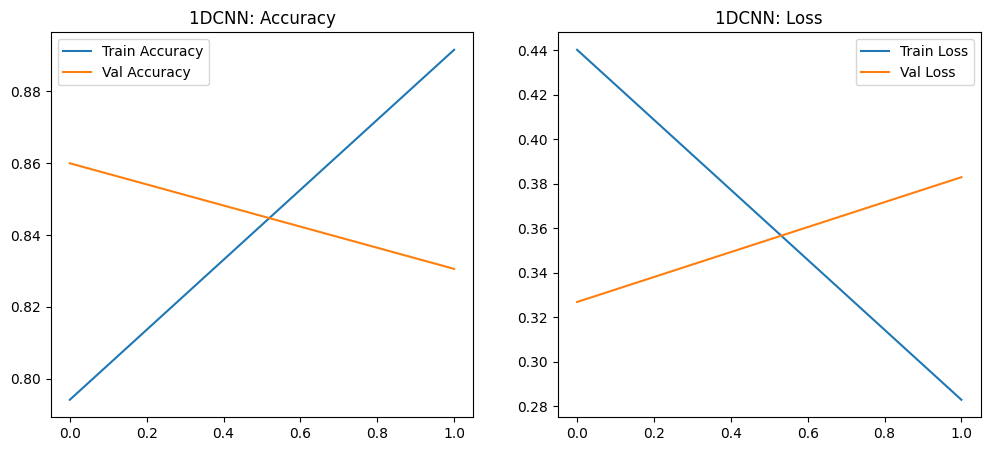

In [52]:
#1DCNN Hyperparameter Tuned Training Curve

acc_cnn_tuned = history_cnn.history['accuracy']
val_acc_cnn_tuned = history_cnn.history['val_accuracy']
loss_gru = history_cnn.history['accuracy']
val_loss_gru = history_cnn.history['val_loss']

epochs = range(1,len(acc_cnn_tuned)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('1DCNN: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('1DCNN: Loss')
plt.legend()
plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.93      0.84      2462
           1       0.92      0.73      0.81      2538

    accuracy                           0.83      5000
   macro avg       0.84      0.83      0.83      5000
weighted avg       0.85      0.83      0.83      5000



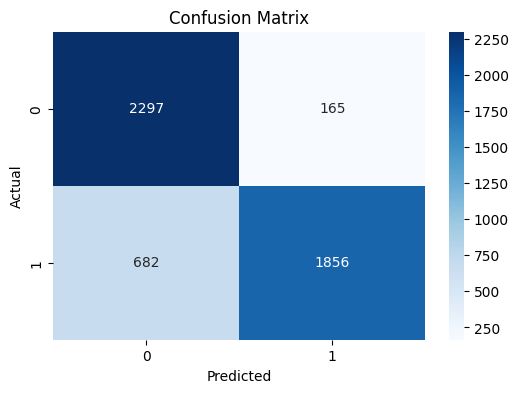

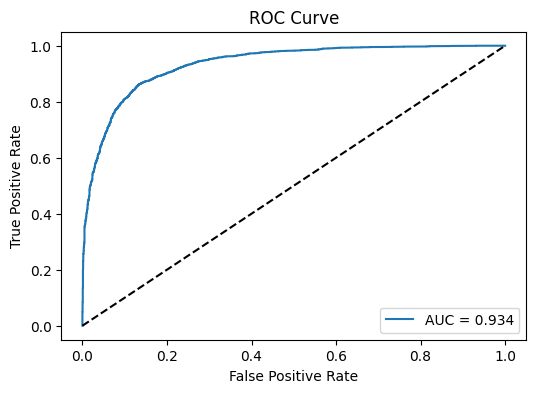

In [53]:
y_true_cnn_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_cnn_tuned = best_model_cnn.predict(val_ds)
y_pred_cnn_tuned = (y_pred_probs_cnn_tuned > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true_cnn_tuned, y_pred_cnn_tuned))

# Confusion Matrix
cm_cnn_tuned = confusion_matrix(y_true_cnn_tuned, y_pred_cnn_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#ROC AUC Curve

fpr_cnn_tuned, tpr_cnn_tuned, thresholds_cnn_tuned = roc_curve(y_true_cnn_tuned, y_pred_probs_cnn_tuned)
roc_auc_cnn_tuned = auc(fpr_cnn_tuned, tpr_cnn_tuned)

plt.figure(figsize=(6,4))
plt.plot(fpr_cnn_tuned, tpr_cnn_tuned, label=f"AUC = {roc_auc_cnn_tuned:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**1D CNN Summary:**

*   Based on the chosen architecture, I first built a 1D‑CNN model and evaluated its performance using validation accuracy. The results indicated  signs of overfitting.

*   Next, I used Keras Tuner to search for optimal hyperparameters using validation accuracy as the objective.
*   Although the tuner identified a configuration with improved validation accuracy, the training curves still showed overfitting.


*   To address this, I ran Keras Tuner again—this time optimizing for validation loss instead of accuracy. This approach produced a more stable model with better generalization.

*   Using the best hyperparameters identified through the val_loss‑based search, the following section summarizes the optimal hyperparameter combination and provides a brief performance report.
*   Best val_loss: 0.3268674910068512
Best val_accuracy: 0.8600000143051147
{'model_name': '1D_CNN_tuned', 'best_epoch': 1, 'best_val_loss': 0.3268674910068512, 'best_val_accuracy': 0.8600000143051147, 'filters': 64, 'kernel_size': 5, 'spatial_dropout': 0.1, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.01}









## 6.GRU (Standard):

In [54]:
vocab_size = 20000
embedding_dim = 64
sequence_length = 250

#GRU model
gru_model = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),

    GRU(64,dropout=0.2),
    Dense(1,activation='sigmoid')
])

gru_model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
history_gru_standard = gru_model.fit(train_ds,validation_data=val_ds,epochs=5,batch_size=64,callbacks=[stop_early],verbose=2)
gru_model.summary()

#Evaluate
val_loss_gru,val_acc_gru = gru_model.evaluate(val_ds)
print('CNN Val Accuracy',val_acc_gru)
print('CNN Val Loss',val_loss_gru)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 - 10s - 16ms/step - accuracy: 0.5103 - loss: 0.6931 - val_accuracy: 0.5096 - val_loss: 0.6920
Epoch 2/5
625/625 - 8s - 13ms/step - accuracy: 0.5598 - loss: 0.6690 - val_accuracy: 0.5468 - val_loss: 0.6808
Epoch 3/5
625/625 - 8s - 12ms/step - accuracy: 0.7504 - loss: 0.5023 - val_accuracy: 0.8156 - val_loss: 0.4276
Epoch 4/5
625/625 - 10s - 17ms/step - accuracy: 0.8835 - loss: 0.2938 - val_accuracy: 0.8566 - val_loss: 0.3392
Epoch 5/5
625/625 - 8s - 13ms/step - accuracy: 0.9342 - loss: 0.1804 - val_accuracy: 0.8546 - val_loss: 0.3784


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,915,077 (14.93 MB)

 Trainable params: 1,305,025 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,610,052 (9.96 MB)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8586 - loss: 0.3357
CNN Val Accuracy 0.8565999865531921
CNN Val Loss 0.3391915261745453


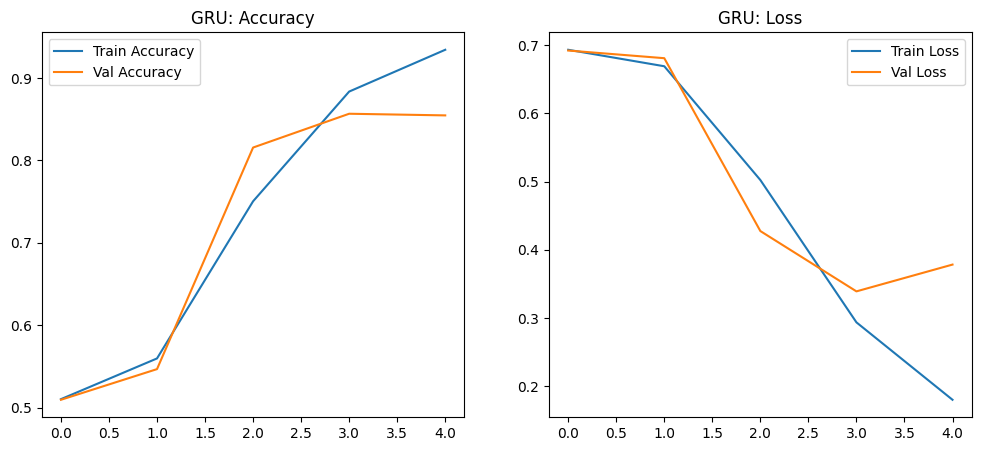

In [55]:
#GRU Training Curve

acc_gru = history_gru_standard.history['accuracy']
val_acc_gru = history_gru_standard.history['val_accuracy']
loss_gru = history_gru_standard.history['accuracy']
val_loss_gru = history_gru_standard.history['val_loss']

epochs = range(1,len(acc_gru)+1)

#Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_gru_standard.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru_standard.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU: Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_gru_standard.history['loss'], label='Train Loss')
plt.plot(history_gru_standard.history['val_loss'], label='Val Loss')
plt.title('GRU: Loss')
plt.legend()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      2462
           1       0.87      0.84      0.86      2538

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



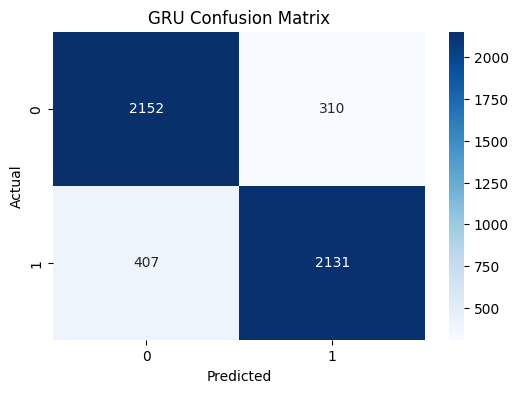

In [56]:
#Classification Report
y_true_gru = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru = gru_model.predict(val_ds)
y_pred_gru = (y_pred_probs_gru > 0.5).astype("int32")

print(classification_report(y_true_gru, y_pred_gru))

#Confusion Matrix

cm_gru = confusion_matrix(y_true_gru, y_pred_gru)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

A Gated Recurrent Unit model is a type of RNN model which learns from  sequential data and simple and faster.they are less likely to overfit.

1.The training accuracy increases from 0.5 to 0.9 steadily and trianing loss also decreaes steadily.
2.Similarly, val accuracy increases and reaches till 0.84 which implies the model is learning well.
3.From the classification report, the model identifies most of the True positives and True negatives.
4.F1 score of 0.86 also indicates the model performs well.

Next, I performed hyper parameter tuning on the GRU model using keras Tuner.

rate = [0.1,0.2,0.3]
units = [32,64]
dropout = [0.2,0.3]
lr = [1e-3,5e-4]

The Tuner will test multiple combinations and the best model will be selected based on the minimum validation loss.Early stoppping is used to restore best weights.



## 7.GRU (Tuned)

In [57]:
#Hypertuned GRU
#rate = [0.1,0.2,0.3]
#units = [32,64]
#dropout = [0.2,0.3]
#lr = [1e-3,5e-4]

def build_gru_hypermodel(gru):
    model = keras.Sequential()

    #Embedding Layer
    model.add(layers.Embedding(input_dim=20000, output_dim=64, input_length=250))

    #SpatialDropout
    model.add(layers.SpatialDropout1D(
        rate=gru.Float('spatial_dropout', min_value=0.1, max_value=0.3, step=0.1)
    ))

    units = gru.Choice("units",[32,64])
    dropout = gru.Choice("dropout",[0.2,0.3])

    model.add(layers.GRU(
        units,
        dropout=dropout
    ))

    #Dense Layer Units
    model.add(layers.Dense(
        units=gru.Int('dense_units', min_value=32, max_value=64, step=32),
        activation='relu'
    ))

    model.add(layers.Dense(1, activation='sigmoid'))


#Learning Rate
    lr = gru.Choice('learning_rate', values=[1e-3,5e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_gru = kt.RandomSearch(
    build_gru_hypermodel,
    objective='val_loss',
    max_trials=5,
    directory='gru_tuning',
    project_name='imdb_gru_search'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2,restore_best_weights=True)

tuner_gru.search(train_ds, validation_data=val_ds, epochs=5, callbacks=[stop_early])

# Get the best hyperparameters
best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
best_hps_gru.values

print("Best Hyperparameters:")
print(f"Spatial Dropout: {best_hps_gru.get('spatial_dropout')}")
print(f"GRU Units: {best_hps_gru.get('units')}")
print(f"Dropout: {best_hps_gru.get('dropout')}")
print(f"Dense Units: {best_hps_gru.get('dense_units')}")
print(f"Learning Rate: {best_hps_gru.get('learning_rate')}")

# Build the model with the best hyperparameters and train it
best_gru_model = tuner_gru.hypermodel.build(best_hps_gru)
history_gru = best_gru_model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=[stop_early],verbose=2)

val_loss_history_gru = history_gru.history["val_loss"]
best_epoch_gru = int(np.argmin(val_loss_history_gru))+ 1

gru_tuned_result = {
    "model_name": "GRU_tuned",
    "best_epoch": best_epoch_gru,
    "best_val_loss": float(min(val_loss_history_gru)),
    "best_val_accuracy": float(max(history_gru.history["val_accuracy"])),
    "units": best_hps_gru.get("units"),
    "dropout": best_hps_gru.get("dropout"),
    "dense_units": best_hps_gru.get("dense_units"),
    "learning_rate": best_hps_gru.get("learning_rate"),
}

print(gru_tuned_result)


Trial 5 Complete [00h 00m 51s]
val_loss: 0.3249303996562958

Best val_loss So Far: 0.30446991324424744
Total elapsed time: 00h 04m 23s
Best Hyperparameters:
Spatial Dropout: 0.2
GRU Units: 32
Dropout: 0.2
Dense Units: 64
Learning Rate: 0.001
Epoch 1/2
625/625 - 11s - 17ms/step - accuracy: 0.5113 - loss: 0.6931 - val_accuracy: 0.5154 - val_loss: 0.6918
Epoch 2/2
625/625 - 9s - 14ms/step - accuracy: 0.5378 - loss: 0.6778 - val_accuracy: 0.5002 - val_loss: 0.6911
{'model_name': 'GRU_tuned', 'best_epoch': 2, 'best_val_loss': 0.6910777688026428, 'best_val_accuracy': 0.5153999924659729, 'units': 32, 'dropout': 0.2, 'dense_units': 64, 'learning_rate': 0.001}


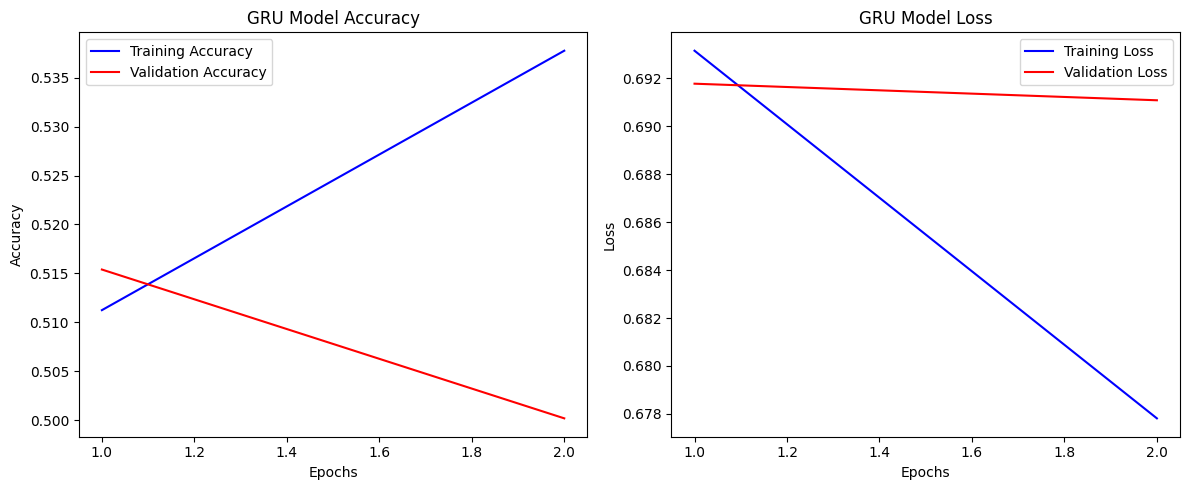

In [58]:
#Loss and Accuracy Plot

acc_gru_tuned = history_gru.history['accuracy']
val_acc_gru_tuned = history_gru.history['val_accuracy']
loss_gru_tuned = history_gru.history['loss']
val_loss_gru_tuned = history_gru.history['val_loss']

epochs = range(1, len(acc_gru_tuned) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc_gru_tuned, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc_gru_tuned, 'r-', label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss_gru_tuned, 'b-', label='Training Loss')
plt.plot(epochs, val_loss_gru_tuned, 'r-', label='Validation Loss')
plt.title('GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.49      0.70      0.58      2462
           1       0.51      0.31      0.39      2538

    accuracy                           0.50      5000
   macro avg       0.50      0.50      0.48      5000
weighted avg       0.50      0.50      0.48      5000



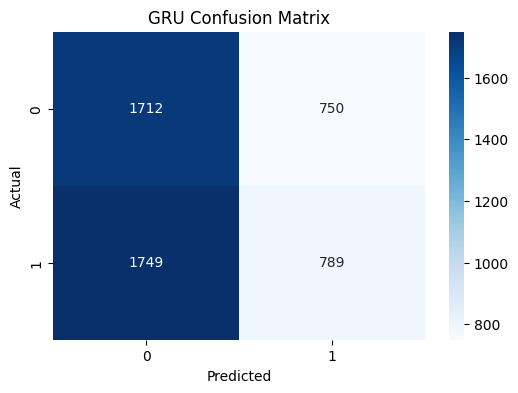

In [59]:
#Classification Report
y_true_gru_tuned = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs_gru_tuned = best_gru_model.predict(val_ds)
y_pred_gru_tuned = (y_pred_probs_gru_tuned > 0.5).astype("int32")

print(classification_report(y_true_gru_tuned, y_pred_gru_tuned))

#Confusion Matrix

cm_gru_tuned = confusion_matrix(y_true_gru_tuned, y_pred_gru_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru_tuned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()


The below 2 blocks of code are for storing the model summaries , metric values and architecture. If its needed to be done in a separate notebook so that the models need not be trained again.

In [60]:
import json
import pickle
import os
import numpy as np
from sklearn.metrics import classification_report

def save_full_model_assets(model, history, name, val_ds):
    # Create directory
    folder = 'imdb_models'
    if not os.path.exists(folder): os.makedirs(folder)

    # Save Model Architecture Summary as string
    summary_list = []
    model.summary(print_fn=lambda x: summary_list.append(x))
    with open(f'{folder}/{name}_summary.txt', 'w') as f:
        f.write("\n".join(summary_list))

    # Save Training History (Acc, Loss for both Train & Val)
    with open(f'{folder}/{name}_history.pkl', 'wb') as f:
        pickle.dump(history.history, f)

    # Generate and Save Detailed Metrics (Precision, Recall, F1)
    # Get true labels and predictions
    y_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_pred_probs = model.predict(val_ds)
    y_pred = (y_pred_probs > 0.5).astype("int32")

    # Get classification report as a dictionary
    report = classification_report(y_true, y_pred, output_dict=True)

    # Save JSON for the comparison table
    metrics = {
        "model_name": name,
        "val_accuracy": report['accuracy'],
        "val_loss": history.history['val_loss'][-1],
        "precision": report['weighted avg']['precision'],
        "recall": report['weighted avg']['recall'],
        "f1_score": report['weighted avg']['f1-score']
    }

    with open(f'{folder}/{name}_metrics.json', 'w') as f:
        json.dump(metrics, f)

    # Save the .keras model file
    model.save(f'{folder}/{name}_model.keras')
    print(f"All assets for {name} saved to {folder}/")

In [61]:
save_full_model_assets(cnn_model, history_cnn_standard, "CNN_standard", val_ds)
save_full_model_assets(best_model_cnn, history_cnn, "CNN_tuned", val_ds)
save_full_model_assets(gru_model, history_gru_standard, "GRU_Standard", val_ds)
save_full_model_assets(best_gru_model, history_gru, "GRU_tuned", val_ds)
save_full_model_assets(bilstm_model_1, history_bilstm_1, "BiLSTM Standard",val_ds)
save_full_model_assets(final_bilstm_model, history_bilstm_tuned, "BiLSTM_tuned", val_ds)
save_full_model_assets(model, history, "Baseline", val_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
All assets for CNN_standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
All assets for CNN_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
All assets for GRU_Standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
All assets for GRU_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
All assets for BiLSTM Standard saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
All assets for BiLSTM_tuned saved to imdb_models/


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
All assets for Baseline saved to imdb_models/


# Model Summary

In [77]:

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

def eval_model_to_row(model, history, name, val_ds):
    # Choose best epoch by lowest validation loss
    val_losses = history.history['val_loss']
    best_idx = int(np.argmin(val_losses))  # epoch index with lowest val_loss

    best_val_loss = history.history['val_loss'][best_idx]
    best_val_acc  = history.history['val_accuracy'][best_idx]

    #Prec ision / Recall / F1 from sklearn
    y_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_pred_probs = model.predict(val_ds)
    y_pred = (y_pred_probs > 0.5).astype("int32")

    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)

    return {
        "Model": name,
        "Val_Acc": best_val_acc,
        "Val_Loss": best_val_loss,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

rows = []
rows.append(eval_model_to_row(model,             history,             "Baseline",        val_ds))
rows.append(eval_model_to_row(bilstm_model_1,    history_bilstm_1,    "BiLSTM Standard", val_ds))
rows.append(eval_model_to_row(final_bilstm_model, history_bilstm_tuned, "BiLSTM Tuned",  val_ds))
rows.append(eval_model_to_row(cnn_model,         history_cnn_standard,"CNN Standard",   val_ds))
rows.append(eval_model_to_row(best_model_cnn,    history_cnn,         "CNN Tuned",      val_ds))
rows.append(eval_model_to_row(gru_model,         history_gru_standard,"GRU Standard",   val_ds))
rows.append(eval_model_to_row(best_gru_model,    history_gru,         "GRU Tuned",      val_ds))

results_df = pd.DataFrame(rows)
print(results_df)

df_performance = pd.DataFrame(results_df)
#print(df_performance.to_string(index=False))

styled_df = df_performance.style.highlight_max(subset=['Val_Acc', 'F1'], color='lightgreen') \
                                .highlight_min(subset=['Val_Loss'], color='lightgreen') \
                                .format(precision=4)
display(styled_df)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
             Model  Val_Acc  Val_Loss  Precision    Recall        F1
0         Baseline   0.8654  0.308341   0.890539  0.827029  0.857610
1  BiLSTM Standard   0.8562  0.350932   0.849942  0.870370  0.860035
2     BiLSTM Tuned   0.8544  0.365649   0.844106  0.874704  0.859133
3     CNN Standard   0.8660  0.346396   0.848632  0.892435  0.869983
4        CNN Tuned   0.8600  0.326867   0.918357  0.731284  0.814214
5     GRU Standard   0.8566  0.339192   0.873003  0.839638  0.855995
6        GRU Tuned   0.5002  0.691078   0.512671  0.310875  0.387049


,Model,Val_Acc,Val_Loss,Precision,Recall,F1
0,Baseline,0.8654,0.3083,0.8905,0.8270,0.8576
1,BiLSTM Standard,0.8562,0.3509,0.8499,0.8704,0.8600
2,BiLSTM Tuned,0.8544,0.3656,0.8441,0.8747,0.8591
3,CNN Standard,0.8660,0.3464,0.8486,0.8924,0.8700
4,CNN Tuned,0.8600,0.3269,0.9184,0.7313,0.8142
5,GRU Standard,0.8566,0.3392,0.8730,0.8396,0.8560
6,GRU Tuned,0.5002,0.6911,0.5127,0.3109,0.3870


**Overall Performance:**

**Best Model:** The 1D CNN standard achieved the highest validation accuracy  and the highest F1 score(0.87) which indicates there is best balance between precision and recall.

**Strong Baseline: **The baseline model obtained slightly lower validation accuracy(0.8654) and F1(0.85) but lowest validation loss which indicates model is good.

**Other recurrent models:**BiLSTM nad GRU didint surpass the other 2 models in validation loss.Overall the GRU tuned model showed weak val_loss  and poor F1.

**Key Observations:**
The CNN Standard model is the best model among all the models since it showed best val_accuracy and F1 score.

The baseline model remains a strong reference point and shows that a simple architecture can perform as well as complex models, which has best validation loss.

More complex and heavily tuned models did not improve the validation results and in case of GRU Tuned the performance is very poor.


# Conclusion

Although the 1D CNN model show mild overfitting , it consistently achieves the highest validation accuracy , lowest validation loss and strongest F1 score among all models.This indicates that CNN generalizes well when compared to other models .It works well on unseen data compared to BiLSTM,GRU.

Thus, CNN is seleceted as the best performing model.


In [79]:
#CNN STANDARD

cnn_model_test = keras.Sequential([
    layers.Embedding(
    input_dim = vocab_size,
    output_dim = embedding_dim,
    input_length = sequence_length
),
    layers.SpatialDropout1D(0.2),
    layers.Conv1D(filters=64,kernel_size=5,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)) ,
    layers.GlobalMaxPooling1D(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')])

cnn_model_test.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

#Train Model
early_stop_cnn = keras.callbacks.EarlyStopping(monitor='val_loss',patience=2)
history_cnn_standard = cnn_model_test.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop_cnn])
cnn_model_test.summary()

#Evaluate
test_loss_cnn,test_acc_cnn = cnn_model_test.evaluate(test_ds)
print('CNN Test Accuracy',test_acc_cnn)
print('CNN Test Loss',test_loss_cnn)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6304 - loss: 0.6503 - val_accuracy: 0.8412 - val_loss: 0.3890
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8594 - loss: 0.3682 - val_accuracy: 0.8650 - val_loss: 0.3573
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9223 - loss: 0.2482 - val_accuracy: 0.8652 - val_loss: 0.3773
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9606 - loss: 0.1586 - val_accuracy: 0.8598 - val_loss: 0.4488


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 250, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 246, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,914,309 (14.93 MB)

 Trainable params: 1,304,769 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,609,540 (9.95 MB)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8601 - loss: 0.4469
CNN Test Accuracy 0.8569599986076355
CNN Test Loss 0.44880178570747375


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     12500
           1       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



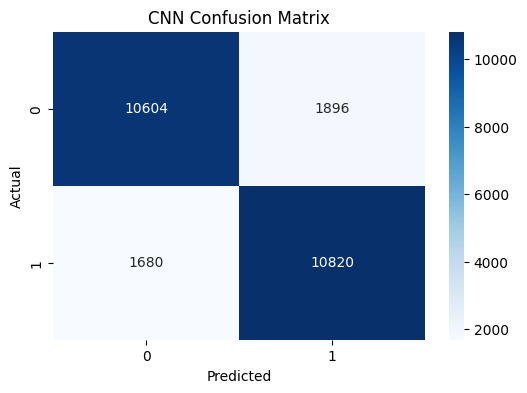

In [80]:

#Classification Report
y_true_cnn_test = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs_cnn_test = cnn_model_test.predict(test_ds)
y_pred_cnn_test = (y_pred_probs_cnn_test > 0.5).astype("int32")

print(classification_report(y_true_cnn_test, y_pred_cnn_test))

#Confusion Matrix

cm_cnn_test = confusion_matrix(y_true_cnn_test, y_pred_cnn_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn_test, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

CNN Standard model is implemented on the test set and found that the accuracy is 0.85 and loss is 0.44.Out of 25000 samples there are TP(10604) and TN(10820)
which means 21424 samples have been identified correctly.3576 has not been identified correctly.

The model showed a good F1 score of 0.86.Model is slightly better at identifying positive reviews than negative reviews.

# Improvements

1.   We can try lemmatization or stemming instead of using lowercase and punctuation.
2.   We can keep some punctuation such as '!' or '?' since they include sentiments.
1.   Other hig performing models like BERT , Transformers and encoders can be implemented.
1.   No of trials and epocha can be increased.
2.   Diffferent dropout and filter , learning rates can be implemented and tried.
2.   Advanced models like BERT based model can be implemented on the IMDB Classification dataset.



# References


1.   https://www.geeksforgeeks.org/nlp/n-gram-in-nlp/

1.   https://www.geeksforgeeks.org/deep-learning/keras-tuner-for-hyperparameter-optimization/

1.   https://www.numberanalytics.com/blog/gru-text-classification

1.   https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU

1.   https://keras.io/api/layers/convolution_layers/convolution1d/
TensorFlow Hub. (n.d.). BERT uncased English preprocessing model. https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3

1.   TensorFlow Hub. (n.d.). Small BERT: Uncased L-4 H-512 A-8. https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1

1.   Devlin, J., Chang, M.‑W., Lee, K., & Toutanova, K. (2019). BERT: Pre‑training of deep bidirectional transformers for language understanding. Proceedings of NAACL‑HLT. https://arxiv.org/abs/1810.04805
2.   TensoFlow:
Abadi, M., et al. (2016). TensorFlow: Large‑scale machine learning on heterogeneous systems. https://www.tensorflow.org/


2.   TensorFlow Text:

     TensorFlow Text. (n.d.). https://www.tensorflow.org/text




















